# Tech Challenge — Fase 1
## Crescimento vs Eficiência Logística: Impacto na Satisfação do Cliente

**Dataset:** Olist Brazilian E-Commerce (2016–2018)  
**Hipótese central:** O crescimento acelerado da plataforma pressionou a capacidade logística, gerando atrasos crescentes que impactaram negativamente a satisfação dos clientes.

---
**Estrutura da análise:**
1. Setup e preparação dos dados
2. Visão geral do negócio (KPIs)
3. Análise de crescimento
4. Análise de eficiência logística
5. Impacto na satisfação do cliente
6. Conclusões executivas

---
## 1. Setup e Preparação dos Dados

In [248]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'

AZUL   = '#2E86AB'
LARANJA = '#F18F01'
VERMELHO = '#C73E1D'
VERDE   = '#3BB273'
CINZA   = '#6C757D'

In [249]:
df_pedidos = pd.read_csv(
    'data_sets/olist_orders_dataset.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'order_delivered_carrier_date'
    ]
)
df_itens_pedidos = pd.read_csv('data_sets/olist_order_items_dataset.csv')
df_pagamento     = pd.read_csv('data_sets/olist_order_payments_dataset.csv')
df_reviews       = pd.read_csv('data_sets/olist_order_reviews_dataset.csv')
df_vendedores    = pd.read_csv('data_sets/olist_sellers_dataset.csv')
df_produtos      = pd.read_csv('data_sets/olist_products_dataset.csv')
df_clientes      = pd.read_csv('data_sets/olist_customers_dataset.csv')

print('DataFrames carregados:')
for nome, base in {
    'Pedidos': df_pedidos, 'Pagamentos': df_pagamento, 'Clientes': df_clientes,
    'Vendedores': df_vendedores, 'Produtos': df_produtos,
    'Itens': df_itens_pedidos, 'Reviews': df_reviews
}.items():
    print(f'  {nome}: {base.shape[0]:,} linhas x {base.shape[1]} colunas')

DataFrames carregados:
  Pedidos: 99,441 linhas x 8 colunas
  Pagamentos: 103,886 linhas x 5 colunas
  Clientes: 99,441 linhas x 5 colunas
  Vendedores: 3,095 linhas x 4 colunas
  Produtos: 32,951 linhas x 9 colunas
  Itens: 112,650 linhas x 7 colunas
  Reviews: 99,224 linhas x 7 colunas


In [250]:
# Agregações
df_itens_agg = df_itens_pedidos.groupby('order_id').agg(
    vlr_pedido=('price', 'sum'),
    vlr_frete=('freight_value', 'sum'),
    qtd_itens_pedido=('order_item_id', 'count')
).reset_index()

df_pagamento_agg = df_pagamento.groupby('order_id').agg(
    vlr_pagamento=('payment_value', 'sum'),
    qtd_parcelas=('payment_installments', 'max')
).reset_index()

df_reviews_agg = df_reviews[['order_id', 'review_score']].drop_duplicates('order_id')

# Join principal
df = df_pedidos.merge(df_clientes, on='customer_id', how='left') \
               .merge(df_itens_agg, on='order_id', how='left') \
               .merge(df_pagamento_agg, on='order_id', how='left') \
               .merge(df_reviews_agg, on='order_id', how='left')

# Renomear
df.rename(columns={
    'order_id': 'id_pedido', 'customer_id': 'id_cliente',
    'order_status': 'status_pedido', 'customer_unique_id': 'id_uni_cliente',
    'customer_zip_code_prefix': 'cep_cliente', 'customer_city': 'cidade_cliente',
    'customer_state': 'estado_cliente',
    'order_purchase_timestamp': 'data_compra', 'order_approved_at': 'data_aprovacao',
    'order_delivered_carrier_date': 'data_envio',
    'order_delivered_customer_date': 'data_entrega',
    'order_estimated_delivery_date': 'data_prevista',
    'review_score': 'nota_review'
}, inplace=True)

# Features logísticas
df['tempo_entrega']   = (df['data_entrega'] - df['data_compra']).dt.days
df['tempo_aprovacao'] = (df['data_aprovacao'] - df['data_compra']).dt.days
df['dias_adiantado']  = (df['data_prevista'] - df['data_entrega']).dt.days
df['atraso']          = df['data_entrega'] > df['data_prevista']
df['receita_total']   = df['vlr_pedido'] + df['vlr_frete']
df['mes']             = df['data_compra'].dt.to_period('M')
df['ano']             = df['data_compra'].dt.year

# Faixas de tempo de entrega
bins   = [0, 5, 10, 20, 30, 999]
labels = ['1–5d', '6–10d', '11–20d', '21–30d', '>30d']
df['faixa_entrega'] = pd.cut(df['tempo_entrega'], bins=bins, labels=labels)

# Apenas pedidos entregues com dados completos
df_entregues = df[df['status_pedido'] == 'delivered'].dropna(
    subset=['tempo_entrega', 'nota_review', 'atraso']
).copy()

print(f'Total de pedidos: {df.shape[0]:,}')
print(f'Pedidos entregues com review: {df_entregues.shape[0]:,}')

Total de pedidos: 99,441
Pedidos entregues com review: 95,824


---
## 2. Visão Geral do Negócio — KPIs Executivos

In [251]:
pedidos_total      = df['id_pedido'].nunique()
clientes_total     = df['id_uni_cliente'].nunique()
sellers_total      = df_itens_pedidos['seller_id'].nunique()
receita_total_val  = df['receita_total'].sum()
ticket_medio_val   = receita_total_val / pedidos_total
nota_media_val     = df_entregues['nota_review'].mean()
tempo_entrega_med  = df_entregues['tempo_entrega'].mean()
perc_atraso_val    = df_entregues['atraso'].mean() * 100
frete_medio_val    = df_entregues['vlr_frete'].mean()

kpis = pd.DataFrame({
    'Indicador': [
        'Pedidos totais', 'Clientes únicos', 'Sellers ativos',
        'Receita total', 'Ticket médio', 'Nota média (reviews)',
        'Tempo médio de entrega', '% pedidos atrasados', 'Frete médio'
    ],
    'Valor': [
        f'{pedidos_total:,.0f}', f'{clientes_total:,.0f}', f'{sellers_total:,.0f}',
        f'R$ {receita_total_val:,.0f}', f'R$ {ticket_medio_val:.2f}',
        f'{nota_media_val:.2f} / 5.0',
        f'{tempo_entrega_med:.1f} dias', f'{perc_atraso_val:.1f}%',
        f'R$ {frete_medio_val:.2f}'
    ]
})
kpis

,Indicador,Valor
0,Pedidos totais,"99,441"
1,Clientes únicos,"96,096"
2,Sellers ativos,"3,095"
3,Receita total,"R$ 15,843,553"
4,Ticket médio,R$ 159.33
5,Nota média (reviews),4.16 / 5.0
6,Tempo médio de entrega,12.1 dias
7,% pedidos atrasados,8.0%
8,Frete médio,R$ 22.76


---
## 3. Análise de Crescimento

A Olist experimentou crescimento expressivo entre 2016 e 2018. As análises a seguir quantificam essa expansão em receita, volume de pedidos e ticket médio.

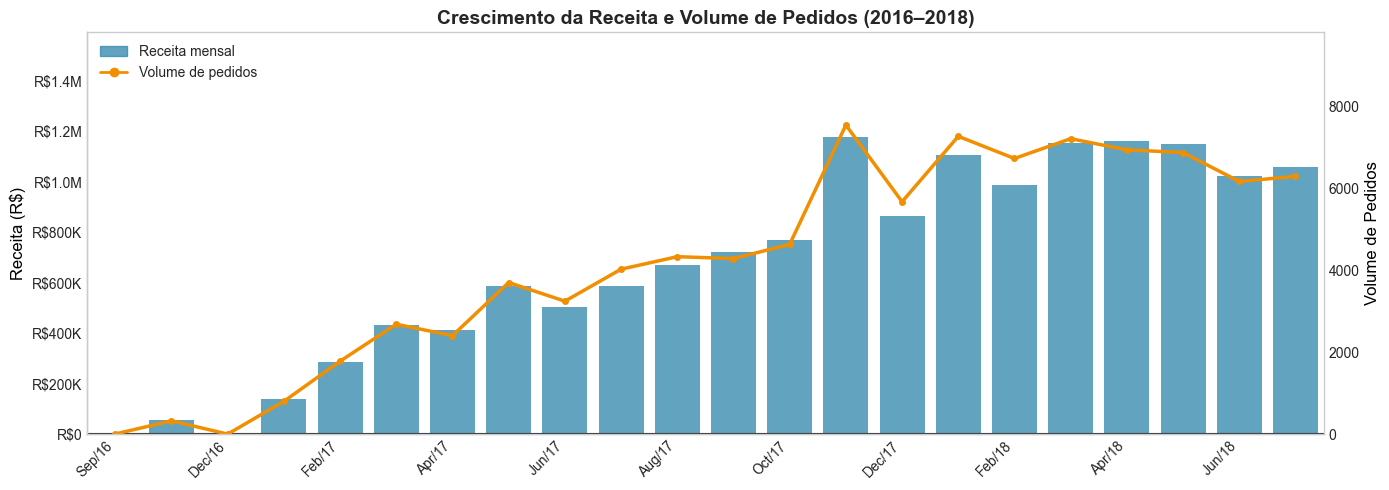

Crescimento médio mensal da receita: 43.9%
Crescimento médio mensal de pedidos: 39.7%


In [252]:
# Receita mensal e volume — cortamos últimos 3 meses (dados incompletos)
receita_mensal  = df.groupby('mes')['receita_total'].sum()[:-3]
pedidos_mensal  = df.groupby('mes')['id_pedido'].nunique()[:-3]
ticket_mensal   = receita_mensal / pedidos_mensal

idx = receita_mensal.index.to_timestamp()
x   = list(range(len(idx)))
labels_x = idx.strftime('%b/%y')

def format_k(v, pos):
    if v >= 1e6: return f'R${v/1e6:.1f}M'
    if v >= 1e3: return f'R${v/1e3:.0f}K'
    return f'R${v:.0f}'

fig, ax1 = plt.subplots(figsize=(14, 5))

bars = ax1.bar(x, receita_mensal.values, color=AZUL, alpha=0.75, label='Receita')
ax2  = ax1.twinx()
ax2.plot(x, pedidos_mensal.values, color=LARANJA, linewidth=2.5, marker='o', markersize=4, label='Pedidos')

ax1.set_ylabel('Receita (R$)', color='black')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(format_k))
ax1.set_ylim(0, receita_mensal.max() * 1.35)
ax1.set_xlim(-0.5, len(x) - 0.5)

ax2.set_ylabel('Volume de Pedidos', color='black')
ax2.set_ylim(0, pedidos_mensal.max() * 1.3)

xticks = range(0, len(labels_x), 2)
ax1.set_xticks(list(xticks))
ax1.set_xticklabels([labels_x[i] for i in xticks], rotation=45, ha='right')
ax1.axhline(y=0, color='black', linewidth=1.5)

patch1 = mpatches.Patch(color=AZUL, alpha=0.75, label='Receita mensal')
line1  = plt.Line2D([0], [0], color=LARANJA, linewidth=2, marker='o', label='Volume de pedidos')
ax1.legend(handles=[patch1, line1], loc='upper left')

ax1.set_title('Crescimento da Receita e Volume de Pedidos (2016–2018)')
for sp in ['top', 'right']: ax1.spines[sp].set_visible(False)
ax1.grid(False); ax2.grid(False)
plt.tight_layout()
plt.show()

cagr_receita  = (receita_mensal.iloc[-1] / receita_mensal.iloc[0]) ** (1/len(x)) - 1
cagr_pedidos  = (pedidos_mensal.iloc[-1] / pedidos_mensal.iloc[0]) ** (1/len(x)) - 1
print(f'Crescimento médio mensal da receita: {cagr_receita*100:.1f}%')
print(f'Crescimento médio mensal de pedidos: {cagr_pedidos*100:.1f}%')

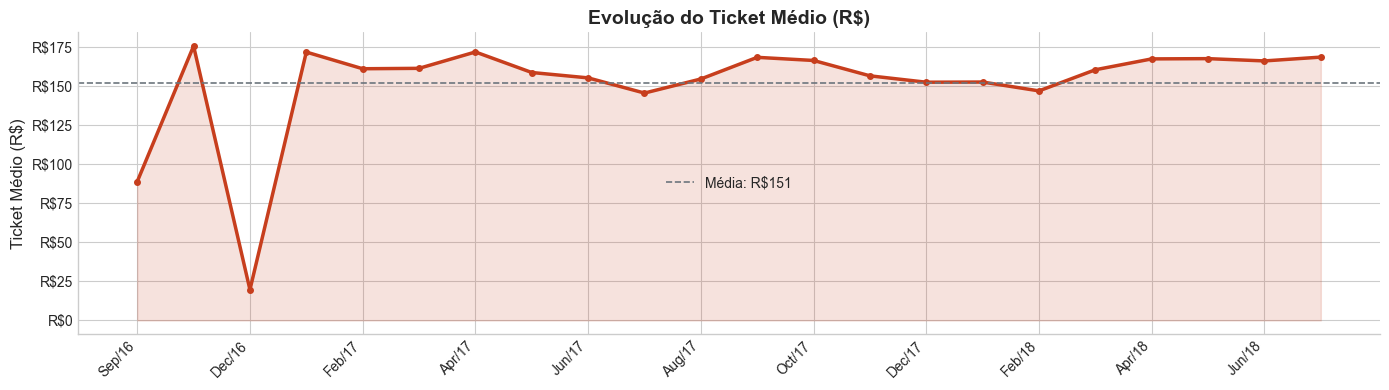

In [253]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(x, ticket_mensal.values, color=VERMELHO, linewidth=2.5, marker='o', markersize=4)
ax.fill_between(x, ticket_mensal.values, alpha=0.15, color=VERMELHO)
ax.axhline(ticket_mensal.mean(), color=CINZA, linestyle='--', linewidth=1.2, label=f'Média: R${ticket_mensal.mean():.0f}')

ax.set_xticks(list(xticks))
ax.set_xticklabels([labels_x[i] for i in xticks], rotation=45, ha='right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'R${v:.0f}'))
ax.set_title('Evolução do Ticket Médio (R$)')
ax.set_ylabel('Ticket Médio (R$)')
ax.legend()
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.show()

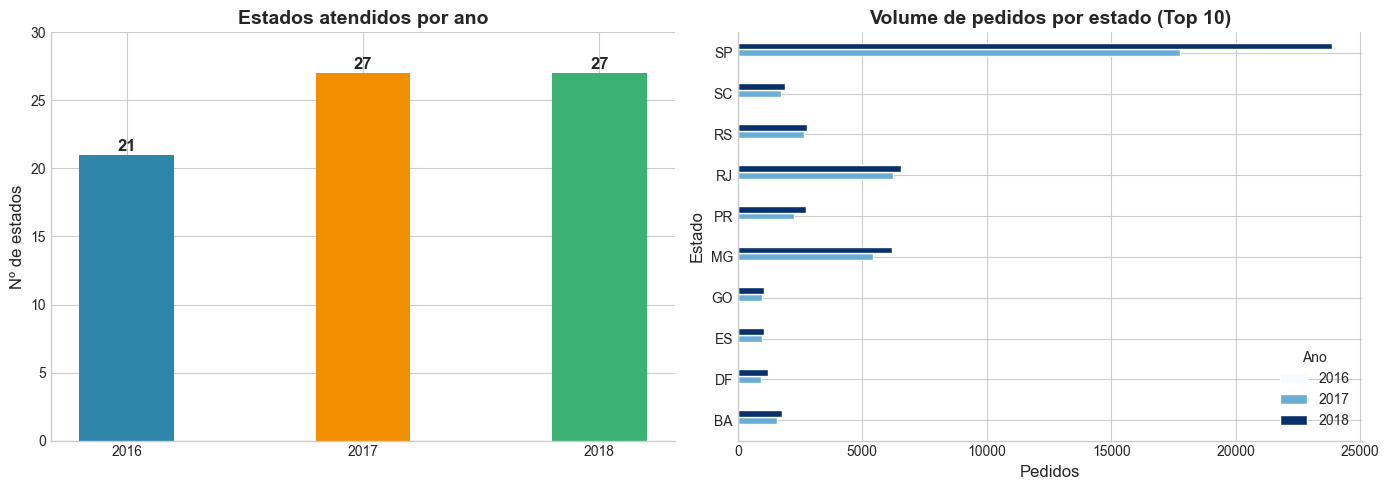

In [254]:
# Expansão geográfica: novos estados por ano
estados_por_ano = df.groupby('ano')['estado_cliente'].nunique().reset_index()
estados_por_ano.columns = ['Ano', 'Estados atendidos']

pedidos_estado = df.groupby(['ano', 'estado_cliente'])['id_pedido'].nunique().reset_index()
pedidos_estado.columns = ['ano', 'estado', 'pedidos']
top_estados = pedidos_estado.groupby('estado')['pedidos'].sum().nlargest(10).index
pedidos_top = pedidos_estado[pedidos_estado['estado'].isin(top_estados)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras: estados atendidos por ano
ax = axes[0]
bars = ax.bar(estados_por_ano['Ano'].astype(str), estados_por_ano['Estados atendidos'],
              color=[AZUL, LARANJA, VERDE], width=0.4)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Estados atendidos por ano')
ax.set_ylabel('Nº de estados')
ax.set_ylim(0, 30)
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

# Barras empilhadas: evolução por top estados
ax2 = axes[1]
pivot = pedidos_top.pivot(index='estado', columns='ano', values='pedidos').fillna(0)
pivot.plot(kind='barh', ax=ax2, colormap='Blues', edgecolor='white')
ax2.set_title('Volume de pedidos por estado (Top 10)')
ax2.set_xlabel('Pedidos')
ax2.set_ylabel('Estado')
ax2.legend(title='Ano')
for sp in ['top', 'right']: ax2.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()

---
## 4. Análise de Eficiência Logística

À medida que o volume cresceu, a capacidade logística foi pressionada. Analisamos aqui a evolução dos atrasos, tempo de entrega e cobertura geográfica.

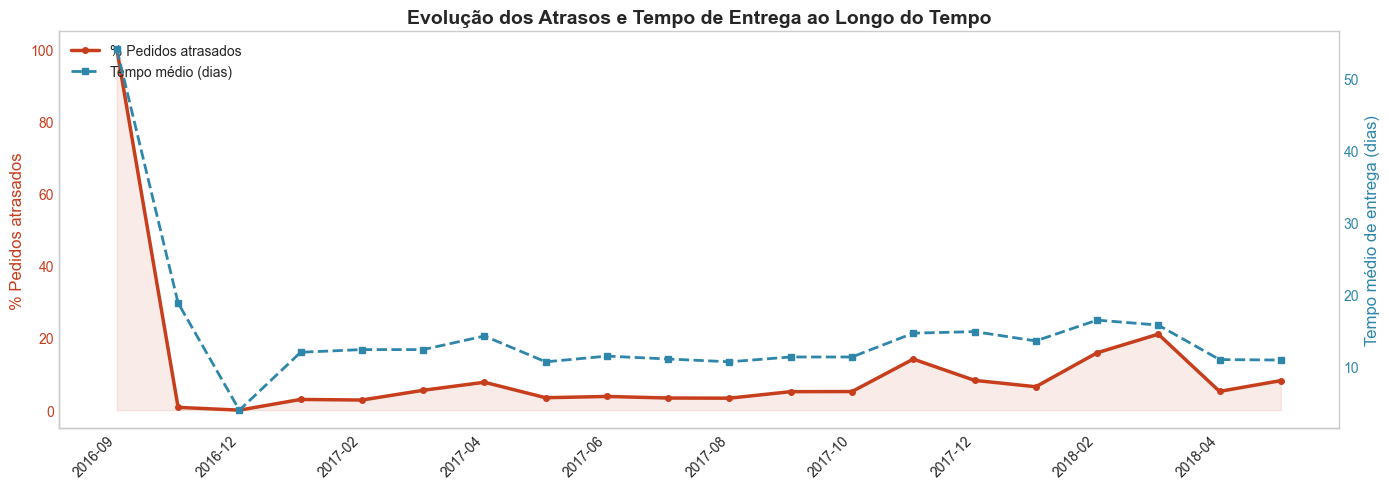

In [255]:
# % atraso e tempo médio de entrega por mês
logistica_mensal = df_entregues.groupby('mes').agg(
    perc_atraso=('atraso', 'mean'),
    tempo_medio=('tempo_entrega', 'mean'),
    pedidos=('id_pedido', 'nunique')
).reset_index()
logistica_mensal = logistica_mensal.iloc[:-3]  # remover meses incompletos
logistica_mensal['perc_atraso'] *= 100
lm_x = list(range(len(logistica_mensal)))
lm_labels = logistica_mensal['mes'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(lm_x, logistica_mensal['perc_atraso'], color=VERMELHO, linewidth=2.5,
         marker='o', markersize=4, label='% Pedidos atrasados')
ax1.fill_between(lm_x, logistica_mensal['perc_atraso'], alpha=0.1, color=VERMELHO)

ax2.plot(lm_x, logistica_mensal['tempo_medio'], color=AZUL, linewidth=2,
         marker='s', markersize=4, linestyle='--', label='Tempo médio (dias)')

ax1.set_ylabel('% Pedidos atrasados', color=VERMELHO)
ax1.tick_params(axis='y', colors=VERMELHO)
ax2.set_ylabel('Tempo médio de entrega (dias)', color=AZUL)
ax2.tick_params(axis='y', colors=AZUL)

xt = range(0, len(lm_labels), 2)
ax1.set_xticks(list(xt))
ax1.set_xticklabels([lm_labels.iloc[i] for i in xt], rotation=45, ha='right')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')
ax1.set_title('Evolução dos Atrasos e Tempo de Entrega ao Longo do Tempo')
for sp in ['top', 'right']: ax1.spines[sp].set_visible(False)
ax1.grid(False); ax2.grid(False)
plt.tight_layout()
plt.show()

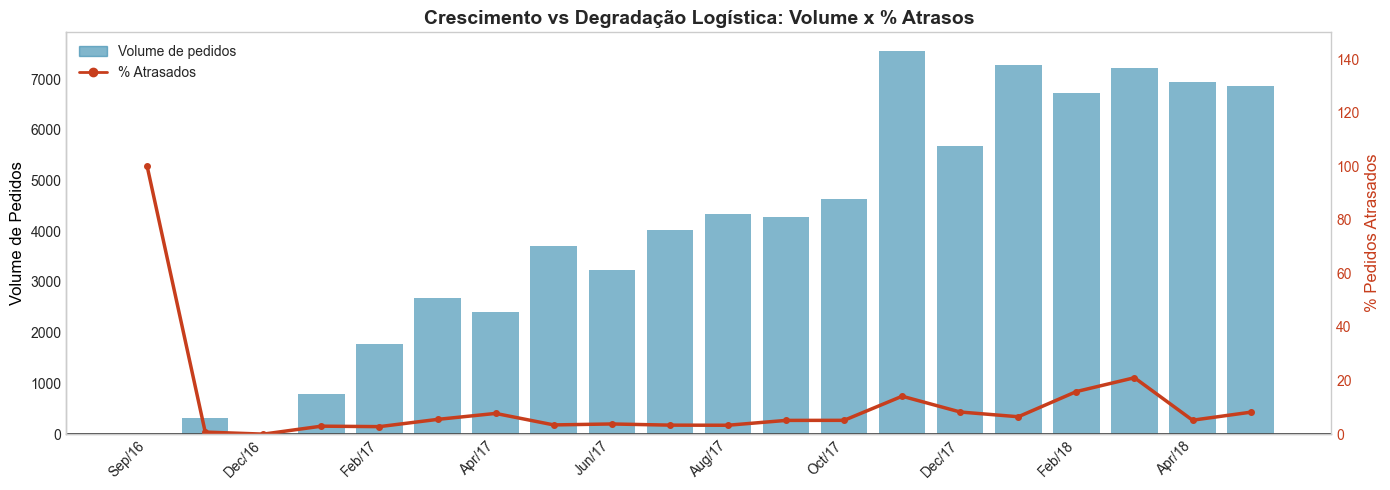

In [256]:
# Crescimento vs degradação logística no mesmo gráfico
pedidos_m = df.groupby('mes')['id_pedido'].nunique().iloc[:-3]
atraso_m  = df_entregues.groupby('mes')['atraso'].mean() * 100
atraso_m  = atraso_m.iloc[:-3]

idx_comum = pedidos_m.index.intersection(atraso_m.index)
pedidos_m = pedidos_m.loc[idx_comum]
atraso_m  = atraso_m.loc[idx_comum]
x_vals    = list(range(len(idx_comum)))
x_labels  = idx_comum.to_timestamp().strftime('%b/%y')

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(x_vals, pedidos_m.values, color=AZUL, alpha=0.6, label='Pedidos/mês')
ax2.plot(x_vals, atraso_m.values, color=VERMELHO, linewidth=2.5,
         marker='o', markersize=4, label='% Atraso')

ax1.set_ylabel('Volume de Pedidos', color='black')
ax2.set_ylabel('% Pedidos Atrasados', color=VERMELHO)
ax2.tick_params(axis='y', colors=VERMELHO)
ax2.set_ylim(0, atraso_m.max() * 1.5)

xt2 = range(0, len(x_labels), 2)
ax1.set_xticks(list(xt2))
ax1.set_xticklabels([x_labels[i] for i in xt2], rotation=45, ha='right')
ax1.axhline(y=0, color='black', linewidth=1.2)

patch1 = mpatches.Patch(color=AZUL, alpha=0.6, label='Volume de pedidos')
line1  = plt.Line2D([0], [0], color=VERMELHO, linewidth=2, marker='o', label='% Atrasados')
ax1.legend(handles=[patch1, line1], loc='upper left')
ax1.set_title('Crescimento vs Degradação Logística: Volume x % Atrasos')
for sp in ['top', 'right']: ax1.spines[sp].set_visible(False)
ax1.grid(False); ax2.grid(False)
plt.tight_layout()
plt.show()

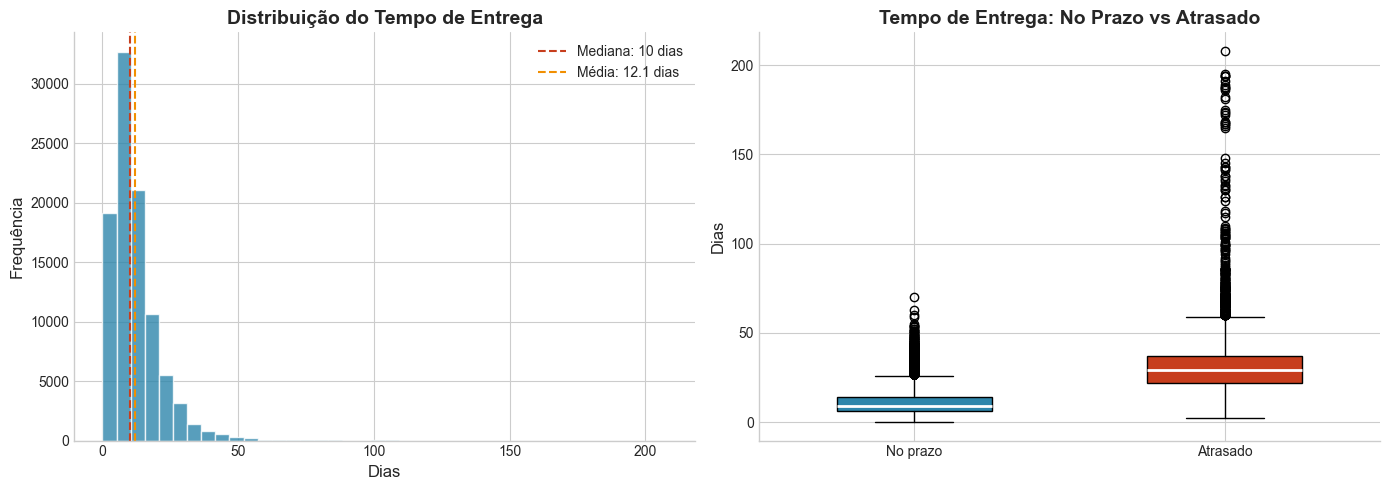

In [257]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma do tempo de entrega
ax = axes[0]
ax.hist(df_entregues['tempo_entrega'].dropna(), bins=40, color=AZUL, alpha=0.8, edgecolor='white')
ax.axvline(df_entregues['tempo_entrega'].median(), color=VERMELHO, linestyle='--',
           linewidth=1.5, label=f"Mediana: {df_entregues['tempo_entrega'].median():.0f} dias")
ax.axvline(df_entregues['tempo_entrega'].mean(), color=LARANJA, linestyle='--',
           linewidth=1.5, label=f"Média: {df_entregues['tempo_entrega'].mean():.1f} dias")
ax.set_title('Distribuição do Tempo de Entrega')
ax.set_xlabel('Dias')
ax.set_ylabel('Frequência')
ax.legend()
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

# Boxplot por status de atraso
ax2 = axes[1]
data_box = [df_entregues[df_entregues['atraso'] == False]['tempo_entrega'].dropna(),
            df_entregues[df_entregues['atraso'] == True]['tempo_entrega'].dropna()]
bp = ax2.boxplot(data_box, patch_artist=True, widths=0.5,
                 medianprops=dict(color='white', linewidth=2))
bp['boxes'][0].set_facecolor(AZUL)
bp['boxes'][1].set_facecolor(VERMELHO)
ax2.set_xticklabels(['No prazo', 'Atrasado'])
ax2.set_title('Tempo de Entrega: No Prazo vs Atrasado')
ax2.set_ylabel('Dias')
for sp in ['top', 'right']: ax2.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()

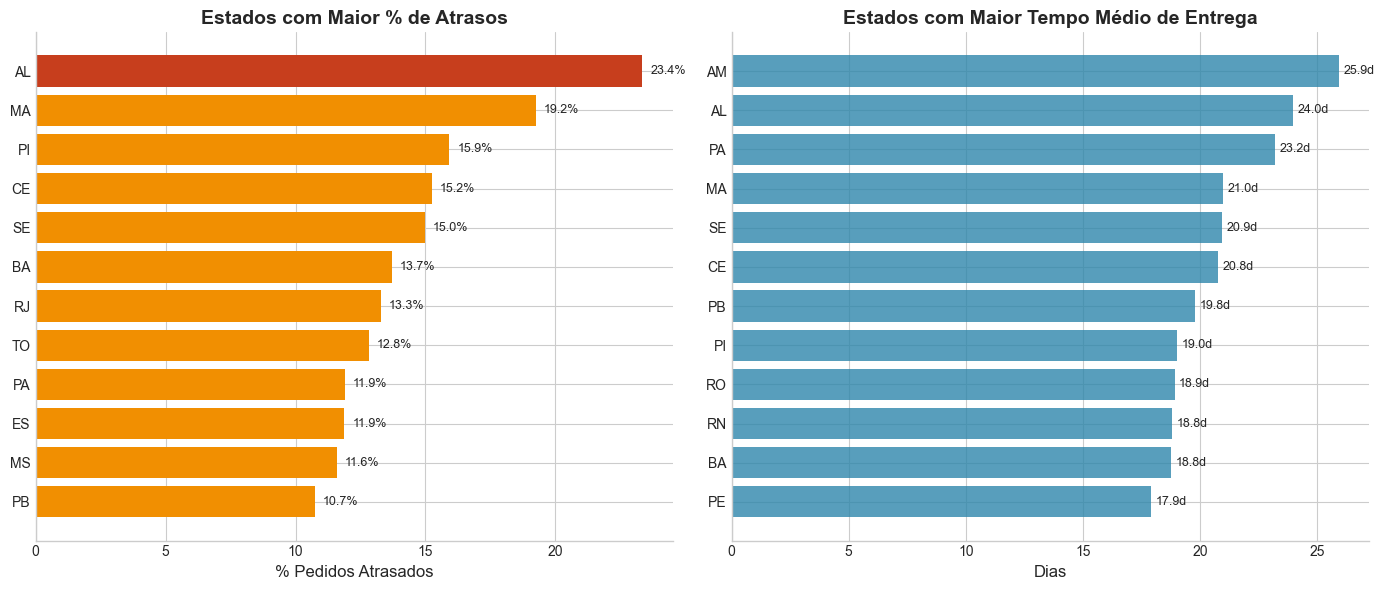

In [258]:
estados_logistica = df_entregues.groupby('estado_cliente').agg(
    pedidos=('id_pedido', 'nunique'),
    perc_atraso=('atraso', 'mean'),
    tempo_medio=('tempo_entrega', 'mean'),
    nota_media=('nota_review', 'mean')
).reset_index()
estados_logistica['perc_atraso'] *= 100
estados_logistica = estados_logistica[estados_logistica['pedidos'] >= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top estados com maior % atraso
ax = axes[0]
top_atraso = estados_logistica.sort_values('perc_atraso', ascending=True).tail(12)
colors = [VERMELHO if v > 20 else LARANJA if v > 10 else AZUL for v in top_atraso['perc_atraso']]
bars = ax.barh(top_atraso['estado_cliente'], top_atraso['perc_atraso'], color=colors)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}%", va='center', fontsize=9)
ax.set_title('Estados com Maior % de Atrasos')
ax.set_xlabel('% Pedidos Atrasados')
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

# Tempo médio de entrega por estado
ax2 = axes[1]
top_tempo = estados_logistica.sort_values('tempo_medio', ascending=True).tail(12)
ax2.barh(top_tempo['estado_cliente'], top_tempo['tempo_medio'], color=AZUL, alpha=0.8)
for i, (_, row) in enumerate(top_tempo.iterrows()):
    ax2.text(row['tempo_medio'] + 0.2, i, f"{row['tempo_medio']:.1f}d", va='center', fontsize=9)
ax2.set_title('Estados com Maior Tempo Médio de Entrega')
ax2.set_xlabel('Dias')
for sp in ['top', 'right']: ax2.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()

---
## 5. Impacto na Satisfação do Cliente

Os atrasos e o tempo de entrega são os principais vetores de insatisfação. As análises abaixo quantificam esse impacto e revelam onde a degradação logística afeta mais a experiência do cliente.

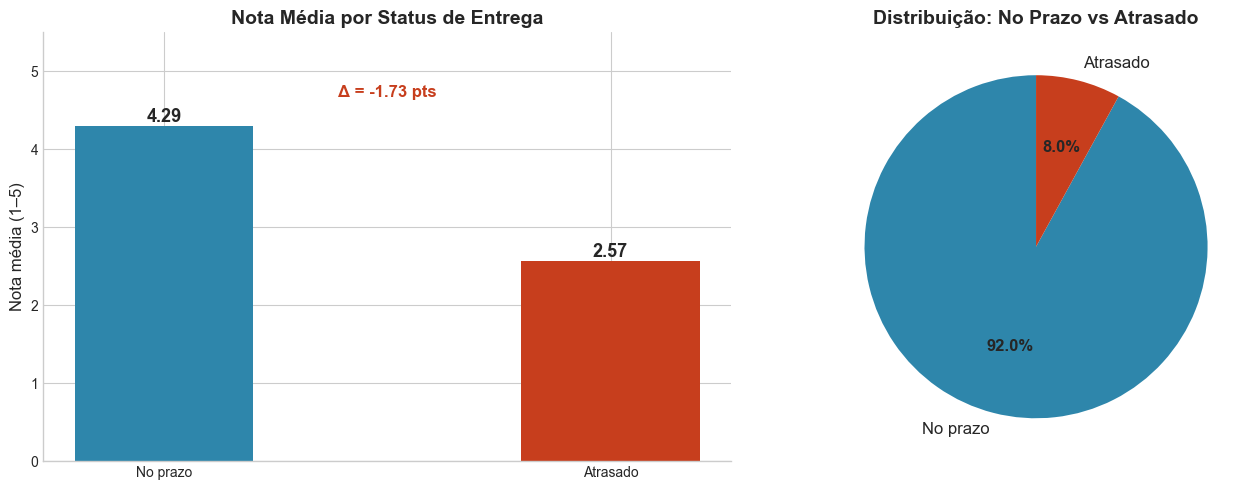

In [259]:
logistica = df_entregues.groupby('atraso').agg(
    nota_media=('nota_review', 'mean'),
    pedidos=('id_pedido', 'nunique'),
    tempo_medio=('tempo_entrega', 'mean')
).reset_index()
logistica['status'] = logistica['atraso'].map({False: 'No prazo', True: 'Atrasado'})
logistica['perc'] = logistica['pedidos'] / logistica['pedidos'].sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nota média por status
ax = axes[0]
cores = [AZUL, VERMELHO]
bars = ax.bar(logistica['status'], logistica['nota_media'], color=cores, width=0.4)
for bar, val in zip(bars, logistica['nota_media']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05,
            f'{val:.2f}', ha='center', fontsize=13, fontweight='bold')
ax.set_ylim(0, 5.5)
ax.set_title('Nota Média por Status de Entrega')
ax.set_ylabel('Nota média (1–5)')
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

diferenca = logistica.loc[logistica['atraso']==False,'nota_media'].values[0] - \
            logistica.loc[logistica['atraso']==True,'nota_media'].values[0]
ax.annotate(f'Δ = -{diferenca:.2f} pts', xy=(0.5, 0.85), xycoords='axes fraction',
            ha='center', fontsize=12, color=VERMELHO, fontweight='bold')

# Distribuição de volume por status
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    logistica['pedidos'], labels=logistica['status'],
    colors=[AZUL, VERMELHO], autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 12}
)
for at in autotexts: at.set_fontweight('bold')
ax2.set_title('Distribuição: No Prazo vs Atrasado')

plt.tight_layout()
plt.show()

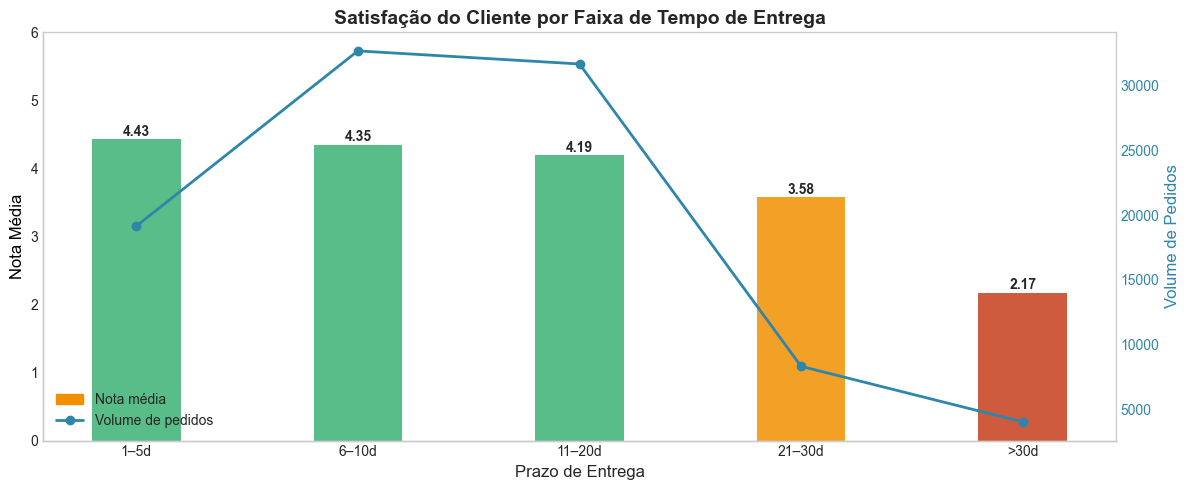

Insight: entregas em até 5 dias têm nota significativamente superior.


In [260]:
faixa_stats = df_entregues.groupby('faixa_entrega', observed=True).agg(
    nota_media=('nota_review', 'mean'),
    pedidos=('id_pedido', 'nunique')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

cor_notas = [VERDE if v >= 4.0 else LARANJA if v >= 3.0 else VERMELHO for v in faixa_stats['nota_media']]
bars = ax1.bar(faixa_stats['faixa_entrega'].astype(str), faixa_stats['nota_media'],
               color=cor_notas, alpha=0.85, width=0.4, label='Nota média')
ax2.plot(faixa_stats['faixa_entrega'].astype(str), faixa_stats['pedidos'],
         color=AZUL, linewidth=2, marker='o', markersize=6, label='Volume de pedidos')

for bar, val in zip(bars, faixa_stats['nota_media']):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

ax1.set_ylim(0, 6)
ax1.set_ylabel('Nota Média', color='black')
ax2.set_ylabel('Volume de Pedidos', color=AZUL)
ax2.tick_params(axis='y', colors=AZUL)
ax1.set_title('Satisfação do Cliente por Faixa de Tempo de Entrega')
ax1.set_xlabel('Prazo de Entrega')

patch1 = mpatches.Patch(color=LARANJA, label='Nota média')
line1  = plt.Line2D([0], [0], color=AZUL, linewidth=2, marker='o', label='Volume de pedidos')
ax1.legend(handles=[patch1, line1], loc='lower left')
for sp in ['top', 'right']: ax1.spines[sp].set_visible(False)
ax1.grid(False); ax2.grid(False)
plt.tight_layout()
plt.show()
print('Insight: entregas em até 5 dias têm nota significativamente superior.')

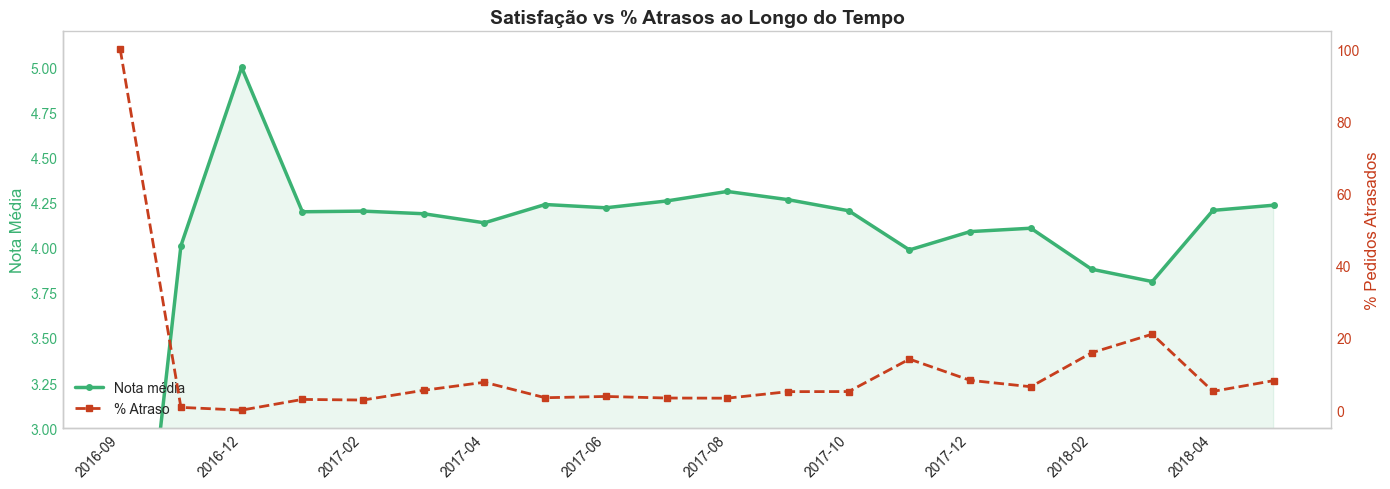

In [261]:
# Nota média por mês vs % atraso no mesmo período
satisf_mensal = df_entregues.groupby('mes').agg(
    nota_media=('nota_review', 'mean'),
    perc_atraso=('atraso', 'mean')
).reset_index()
satisf_mensal = satisf_mensal.iloc[:-3]
satisf_mensal['perc_atraso'] *= 100
sm_x = list(range(len(satisf_mensal)))
sm_labels = satisf_mensal['mes'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(sm_x, satisf_mensal['nota_media'], color=VERDE, linewidth=2.5,
         marker='o', markersize=4, label='Nota média')
ax1.fill_between(sm_x, satisf_mensal['nota_media'], alpha=0.1, color=VERDE)
ax2.plot(sm_x, satisf_mensal['perc_atraso'], color=VERMELHO, linewidth=2,
         marker='s', markersize=4, linestyle='--', label='% Atraso')

ax1.set_ylabel('Nota Média', color=VERDE)
ax1.tick_params(axis='y', colors=VERDE)
ax1.set_ylim(3, 5.2)
ax2.set_ylabel('% Pedidos Atrasados', color=VERMELHO)
ax2.tick_params(axis='y', colors=VERMELHO)

xt3 = range(0, len(sm_labels), 2)
ax1.set_xticks(list(xt3))
ax1.set_xticklabels([sm_labels.iloc[i] for i in xt3], rotation=45, ha='right')

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='lower left')
ax1.set_title('Satisfação vs % Atrasos ao Longo do Tempo')
for sp in ['top', 'right']: ax1.spines[sp].set_visible(False)
ax1.grid(False); ax2.grid(False)
plt.tight_layout()
plt.show()

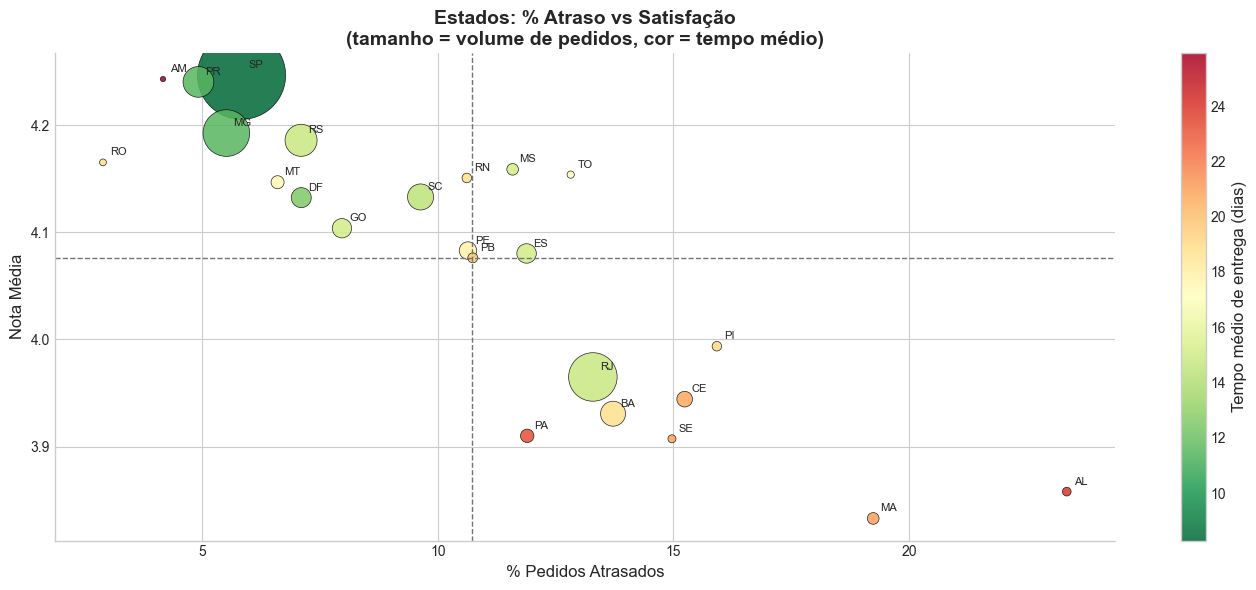

In [262]:
# Mapa de calor: nota média vs % atraso por estado
estados_full = df_entregues.groupby('estado_cliente').agg(
    pedidos=('id_pedido', 'nunique'),
    nota_media=('nota_review', 'mean'),
    perc_atraso=('atraso', 'mean'),
    tempo_medio=('tempo_entrega', 'mean')
).reset_index()
estados_full['perc_atraso'] *= 100
estados_full = estados_full[estados_full['pedidos'] >= 100].sort_values('nota_media', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
sc = ax.scatter(
    estados_full['perc_atraso'], estados_full['nota_media'],
    s=estados_full['pedidos'] / 10,
    c=estados_full['tempo_medio'], cmap='RdYlGn_r',
    alpha=0.85, edgecolors='black', linewidths=0.5
)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Tempo médio de entrega (dias)')

for _, row in estados_full.iterrows():
    ax.annotate(row['estado_cliente'],
                (row['perc_atraso'], row['nota_media']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

ax.axhline(estados_full['nota_media'].mean(), color=CINZA, linestyle='--', linewidth=1)
ax.axvline(estados_full['perc_atraso'].mean(), color=CINZA, linestyle='--', linewidth=1)
ax.set_xlabel('% Pedidos Atrasados')
ax.set_ylabel('Nota Média')
ax.set_title('Estados: % Atraso vs Satisfação\n(tamanho = volume de pedidos, cor = tempo médio)')
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
plt.tight_layout()
plt.show()

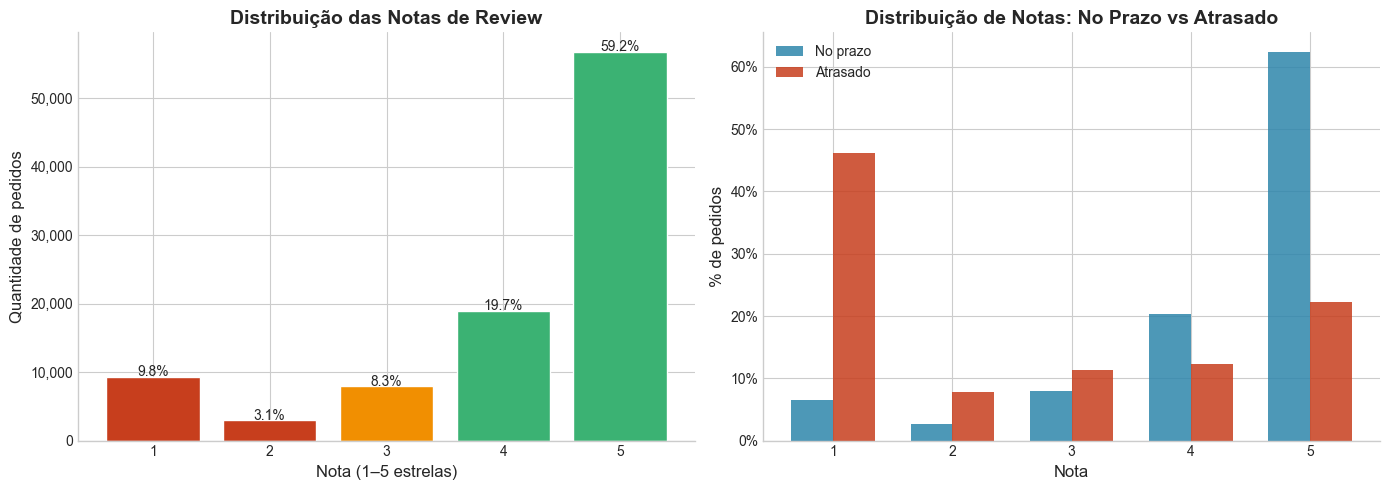

In [263]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de notas
ax = axes[0]
nota_counts = df_entregues['nota_review'].value_counts().sort_index()
cores_nota  = [VERMELHO, VERMELHO, LARANJA, VERDE, VERDE]
bars = ax.bar(nota_counts.index.astype(int), nota_counts.values, color=cores_nota, edgecolor='white')
for bar, val in zip(bars, nota_counts.values):
    pct = val / nota_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{pct:.1f}%', ha='center', fontsize=10)
ax.set_title('Distribuição das Notas de Review')
ax.set_xlabel('Nota (1–5 estrelas)')
ax.set_ylabel('Quantidade de pedidos')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:,.0f}'))
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)

# Notas: atrasados vs no prazo
ax2 = axes[1]
prazo   = df_entregues[df_entregues['atraso'] == False]['nota_review'].value_counts(normalize=True).sort_index() * 100
atrasado = df_entregues[df_entregues['atraso'] == True]['nota_review'].value_counts(normalize=True).sort_index() * 100

x_notas = np.arange(1, 6)
width = 0.35
ax2.bar(x_notas - width/2, prazo.values, width, label='No prazo', color=AZUL, alpha=0.85)
ax2.bar(x_notas + width/2, atrasado.values, width, label='Atrasado', color=VERMELHO, alpha=0.85)
ax2.set_title('Distribuição de Notas: No Prazo vs Atrasado')
ax2.set_xlabel('Nota')
ax2.set_ylabel('% de pedidos')
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax2.legend()
ax2.set_xticks([1, 2, 3, 4, 5])
for sp in ['top', 'right']: ax2.spines[sp].set_visible(False)

plt.tight_layout()
plt.show()

---
## 6. Conclusões Executivas

In [ ]:
from IPython.display import HTML

nota_prazo    = df_entregues[df_entregues['atraso']==False]['nota_review'].mean()
nota_atrasado = df_entregues[df_entregues['atraso']==True]['nota_review'].mean()
nota_rapido   = df_entregues[df_entregues['faixa_entrega']=='1–5d']['nota_review'].mean()
nota_lento    = df_entregues[df_entregues['faixa_entrega']=='>30d']['nota_review'].mean()
vol_inicio    = pedidos_mensal.iloc[0]
vol_fim       = pedidos_mensal.iloc[-1]

resumo = pd.DataFrame({
    'Achado': [
        'Crescimento de pedidos (início → pico)',
        'Nota média geral',
        'Nota média — entrega no prazo',
        'Nota média — entrega atrasada',
        'Impacto do atraso na nota',
        'Nota — entrega em até 5 dias',
        'Nota — entrega acima de 30 dias',
        '% de pedidos atrasados',
        'Tempo médio de entrega'
    ],
    'Valor': [
        f'{vol_inicio:,.0f} → {vol_fim:,.0f} pedidos/mês',
        f'{nota_media_val:.2f} / 5.0',
        f'{nota_prazo:.2f} / 5.0',
        f'{nota_atrasado:.2f} / 5.0',
        f'-{nota_prazo - nota_atrasado:.2f} pontos',
        f'{nota_rapido:.2f} / 5.0',
        f'{nota_lento:.2f} / 5.0',
        f'{perc_atraso_val:.1f}%',
        f'{tempo_entrega_med:.1f} dias'
    ]
})
display(HTML(resumo.to_html(index=False)))

AttributeError: The '.style' accessor requires jinja2

In [ ]:
print('=' * 65)
print('CONCLUSÕES EXECUTIVAS — Crescimento vs Eficiência Logística')
print('=' * 65)
print()
print('1. CRESCIMENTO ACELERADO')
print('   A Olist multiplicou seu volume de pedidos ao longo do período,')
print('   com expansão geográfica para novos estados e cidades.')
print()
print('2. PRESSÃO LOGÍSTICA')
print(f'   {perc_atraso_val:.1f}% dos pedidos entregues chegaram com atraso.')
print(f'   O tempo médio de entrega foi de {tempo_entrega_med:.1f} dias.')
print('   Regiões mais distantes (Norte e Nordeste) concentram')
print('   os maiores índices de atraso e tempo de entrega.')
print()
print('3. IMPACTO NA SATISFAÇÃO')
print(f'   Pedidos atrasados recebem nota média de {nota_atrasado:.2f},')
print(f'   versus {nota_prazo:.2f} para entregas no prazo — queda de'
      f' {nota_prazo-nota_atrasado:.2f} pts.')
print('   Entregas em até 5 dias geram notas significativamente superiores.')
print('   A correlação entre aumento de atrasos e queda de nota é visível')
print('   na análise temporal.')
print()
print('4. RECOMENDAÇÕES')
print('   a) Priorizar SLA de entrega em estados com maior % de atraso.')
print('   b) Investir em centros de distribuição regionais (Norte/Nordeste).')
print('   c) Criar alerta proativo de atraso para reduzir impacto na nota.')
print('   d) Monitorar a relação crescimento x capacidade logística mensalmente.')
print('=' * 65)

CONCLUSÕES EXECUTIVAS — Crescimento vs Eficiência Logística

1. CRESCIMENTO ACELERADO
   A Olist multiplicou seu volume de pedidos ao longo do período,
   com expansão geográfica para novos estados e cidades.

2. PRESSÃO LOGÍSTICA
   8.0% dos pedidos entregues chegaram com atraso.
   O tempo médio de entrega foi de 12.1 dias.
   Regiões mais distantes (Norte e Nordeste) concentram
   os maiores índices de atraso e tempo de entrega.

3. IMPACTO NA SATISFAÇÃO
   Pedidos atrasados recebem nota média de 2.57,
   versus 4.29 para entregas no prazo — queda de 1.73 pts.
   Entregas em até 5 dias geram notas significativamente superiores.
   A correlação entre aumento de atrasos e queda de nota é visível
   na análise temporal.

4. RECOMENDAÇÕES
   a) Priorizar SLA de entrega em estados com maior % de atraso.
   b) Investir em centros de distribuição regionais (Norte/Nordeste).
   c) Criar alerta proativo de atraso para reduzir impacto na nota.
   d) Monitorar a relação crescimento x capacidad